## EDA

In [ ]:
import cv2
import random
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from ..src.config import load_config, target_path, images_path

project_config = load_config(Path('/Users/shpileva/Desktop/big_data/mlops_project/config.ini'))

CSV_PATH = target_path(project_config)
IMAGES_PATH = images_path(project_config)
df = pd.read_csv(CSV_PATH)

In [ ]:
valid_paths, widths, heights, labels, broken_files = [], [], [], [], []

print("Проверка целостности изображений...")
for _, row in df.iterrows():
    image_path = IMAGES_PATH / row['image_name']
    label = row["label"]
    
    img = cv2.imread(image_path)
    
    if img is None:
        broken_files.append(image_path)
        continue
        
    h, w, _ = img.shape
    widths.append(w)
    heights.append(h)
    valid_paths.append(image_path)
    labels.append(label)

print(f"Найдено битых файлов: {len(broken_files)}")

clean_df = pd.DataFrame({
    'image_name': valid_paths,
    'label': labels,
    'width': widths,
    'height': heights
})

OUTPUT_DIR = Path("/Users/shpileva/Desktop/big_data/mlops_project/data")
clean_df.to_csv(OUTPUT_DIR / 'clean_dataset.csv', index=False)
print("Очищенный датасет сохранен в data/clean_dataset.csv")

Проверка целостности изображений...
Найдено битых файлов: 0
Очищенный датасет сохранен в data/clean_dataset.csv


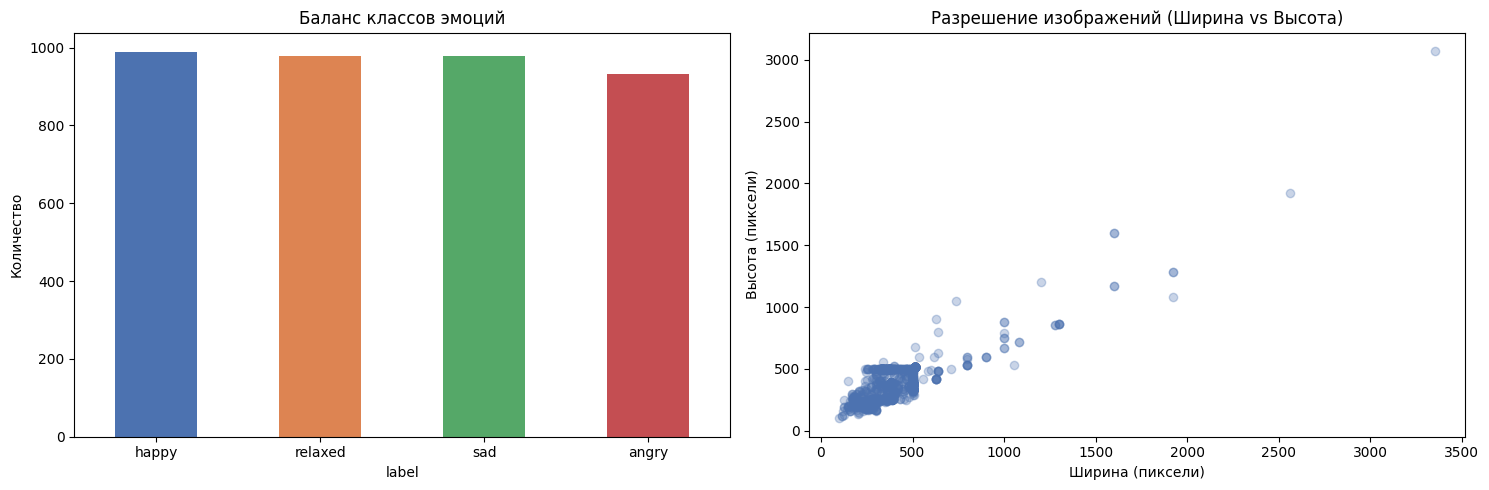

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

clean_df['label'].value_counts().plot(kind='bar', ax=ax1, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
ax1.set_title('Баланс классов эмоций')
ax1.set_ylabel('Количество')
ax1.tick_params(axis='x', rotation=0)

ax2.scatter(clean_df['width'], clean_df['height'], alpha=0.3, color='#4C72B0')
ax2.set_title('Разрешение изображений (Ширина vs Высота)')
ax2.set_xlabel('Ширина (пиксели)')
ax2.set_ylabel('Высота (пиксели)')

plt.tight_layout()
plt.show()

## Подсчет метрик

In [ ]:
import cv2
import pandas as pd
from tqdm import tqdm
from pathlib import Path

from model import VLMModel
from config import load_config, target_path, images_path

config = load_config(Path('/Users/shpileva/Desktop/big_data/mlops_project/config.ini'))

CSV_PATH = target_path(config)
IMAGES_PATH = images_path(config)
MODEL_NAME = config['MODEL']['torch_model_name']
LABEL_MAP = dict(config['PROMPTS'])

print(f"Модель: {MODEL_NAME}")
print(f"Путь к CSV: {CSV_PATH}")
print(f"Маппинг: {LABEL_MAP}")

Модель: openai/clip-vit-base-patch32
Путь к CSV: /Users/shpileva/Desktop/big_data/mlops_project/data/dataset.csv
Маппинг: {'angry': 'a photo of an angry dog', 'happy': 'a photo of a happy dog', 'relaxed': 'a photo of a relaxed dog', 'sad': 'a photo of a sad dog'}


In [8]:

classifier = VLMModel(model_name=MODEL_NAME, processor_name=MODEL_NAME, device="cpu")

df = pd.read_csv(CSV_PATH)
df = df[:100]

results = []
for idx, row in tqdm(df.iterrows(), total=len(df), desc="Process dataset"):
    image_path = IMAGES_PATH / str(row["image_name"])
    image = cv2.imread(image_path)
    pred_label = classifier.predict(image=image, label_map=LABEL_MAP)
    results.append(pred_label)

df['predicted_label'] = results
print(df)

Process dataset: 100%|██████████| 100/100 [00:06<00:00, 15.22it/s]

      label                             image_name predicted_label
0       sad  xwujwWRPeNhQRU8eKC81SMvBDsLquG839.jpg             sad
1       sad  vJzTcQ21bEU9XSKuG8DHzDl3JZRsZo919.jpg             sad
2   relaxed           48126890461_8d18c7c120_b.jpg             sad
3   relaxed            6186600378_b32c96818c_b.jpg         relaxed
4   relaxed            4582932335_6ede1e76a4_b.jpg             sad
..      ...                                    ...             ...
95    angry  MwObpB2V6ua63Srao6FjT7RFpCRCrN287.jpg           angry
96      sad  yRiD49Vu65X12yU1cJYmzW8vENU8LI677.jpg             sad
97    happy  Db7nCgo8dPM70sJZpmthagWzTdcKHQ724.jpg           happy
98      sad  zq3lfQmQ0uVWzfl6yymBDVftU5Vqq5680.jpg           angry
99    happy            6387463257_745cb4fd09_b.jpg           happy

[100 rows x 3 columns]


In [9]:
from sklearn.metrics import classification_report

metrics = classification_report(df['predicted_label'], df['label'])
print(metrics)

              precision    recall  f1-score   support

       angry       0.83      0.61      0.70        31
       happy       0.48      0.86      0.62        14
     relaxed       0.52      0.61      0.56        18
         sad       0.84      0.70      0.76        37

    accuracy                           0.68       100
   macro avg       0.67      0.70      0.66       100
weighted avg       0.73      0.68      0.69       100

